# Session 1: Practical Logging and Procedures in Black-Box Optimization/Meta-heuristics
This session is meant for introducing you to the workflow with working with Meta-heuristics and compare the meta-heuristic algorithms discussed in the course of the first lecture. 

## Part 1: Playing with Optimization Problems/Test Functions
In general, for assessing Black-Box Optimizers, some test functions have been devised to check performance of optimizers. For robust comparison, the optima of each of the functions is known a priori to compute *regret* and *distance to optimum* to the actual optimum. We show hereby some examples (Sphere, Rosenbrock, Rastrigin).

- General Definition of the Sphere Function:
$$f(x_1,x_2, \cdots , x_n) = \sum_{i=1}^{n} x_i^2$$

The optimum is $(0,0)$

- Definition of the original Rosenbrock (2-D) Function (The standard version sets $a=1$ and $b=100$):
$$f(x_1, x_2) = a(1-x_1)^2 + b(x_2 - x_1^2)^2 $$

The optimum is $(1,1)$

- General definition of Rastrigin Function (with $A=10$ and $n$ the dimension):
$$ f(x_1,x_2, \cdots , x_n) = A n + \sum_{i=1}^{n} \left[ x_{i}^2 - A \cos \left(   2 \pi x_{i}  \right)  \right]$$
The optimum is $(0,0)$

### General Definitions
- *Distance to Optimum*: $||\mathbf{x}-\mathbf{x}_{\text{opt}}||_{p}$  with $p=\left \{1,2,3, \ldots \right \}$ (Typically $p=2 \rightarrow$ *Euclidean distance*)
- *Regret* or *Loss*: $|f(\mathbf{x})-f(\mathbf{x}_{\text{opt}})|$

### Usual signature of single objective functions
`def func(x, *args, **kwargs)->float ...`

In [1]:
# Definition of the function to be optimized
import math
def sphere(x:list):
    return sum(xi**2 for xi in x)

def rosenbrock(x:list, a:float=1, b:float=100):
    return a*(1 - x[0])**2  + b*(x[1] - x[0]**2)**2

def rastrigin(x:list, A:float=10):
    return A*len(x) + sum(xi**2 - A*math.cos(2*math.pi*xi) for xi in x)

In [2]:
# TODO: Just run this block!

import numpy as np
import matplotlib.pyplot as plt

# Contour Plotting
def contour(f, xrange=[-5, 5], 
            yrange=[-5, 5], 
            instance=None,
            **kwargs):

    # Unwrap the keyword arguments
    funcname = kwargs.pop('name', '')
    optimum = kwargs.pop('optimum', None)
    levels = kwargs.pop('levels', 50)

    # Create a grid of points
    x = np.linspace(*xrange, 100)
    y = np.linspace(*yrange, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.copy(X)
    for i in range(len(X)):
        for j in range(len(Y)):
            Z[i][j] = f([X[i][j], Y[i][j]])

    # Plot the contour
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, aspect='equal')

    cp = ax.contourf(X, Y, Z, levels=levels, cmap='jet')
    plt.colorbar(cp)

    # Add labels
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')

    if not funcname == '':
        if instance is not None:
            ax.set_title(f'Contour Plot of {funcname} Function - Instance {instance}')
        else:
             ax.set_title(f'Contour Plot of {funcname} Function')

    if optimum is not None:
        ax.plot(optimum[0], optimum[1], 'r*', markersize=10, label='Optimum')
        ax.legend(fontsize="small")

    plt.show()

# Visualization in 3D

def vis3d(f, 
          xrange=[-5, 5], 
          yrange=[-5, 5],
          instance=None,
          **kwargs):

    # Unwrap the keyword arguments
    funcname = kwargs.pop('name', '')
   

    # Create a grid of points
    x = np.linspace(*xrange, 100)
    y = np.linspace(*yrange, 100)
    X, Y = np.meshgrid(x, y)
    Z = np.copy(X)
    for i in range(len(X)):
        for j in range(len(Y)):
            Z[i][j] = f([X[i][j], Y[i][j]])

    # Plot the surface
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X, Y, Z, cmap='jet')

    # Add labels
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_zlabel('$f(x_1, x_2)$')

    if not funcname == '':
        if instance is not None:
            ax.set_title(f'3D Visualization of {funcname} Function - Instance {instance}')
        else:
            ax.set_title(f'3D Visualization of {funcname} Function')

    plt.show()



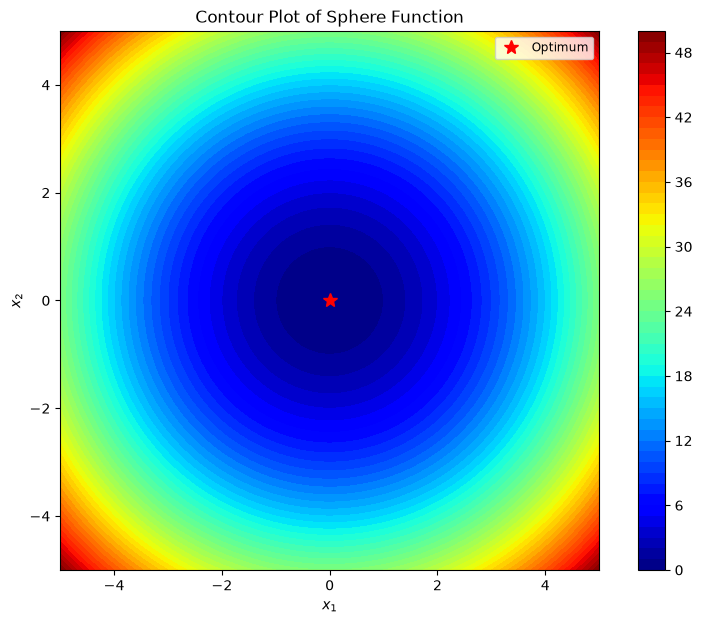

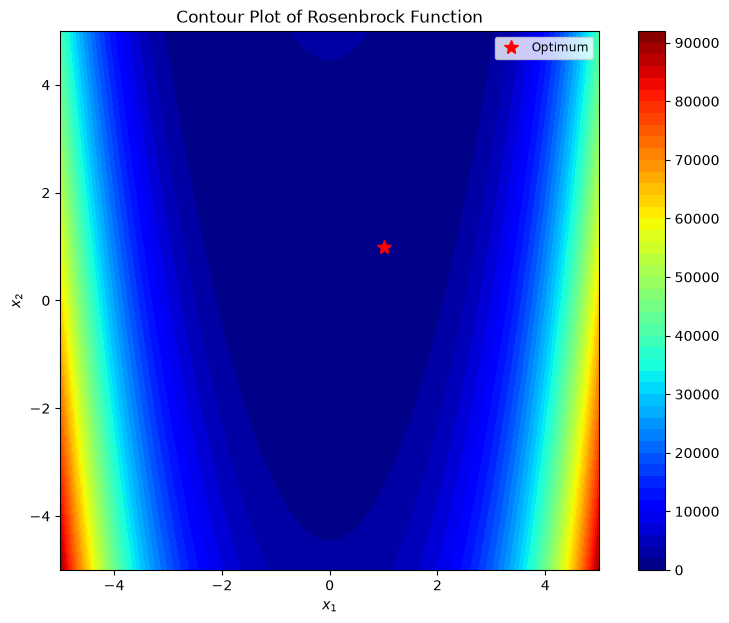

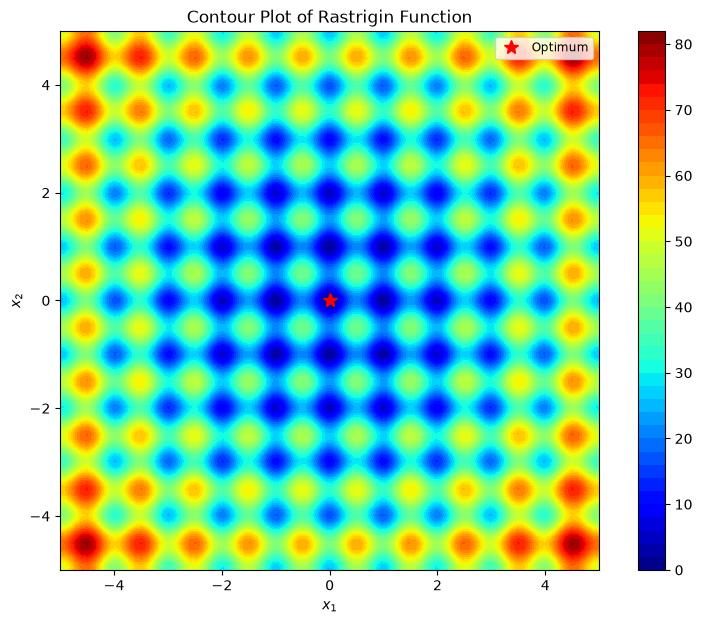

In [3]:
# Dsiplaying the contour plots with respective optima
contour(sphere, name='Sphere', optimum=[0,0])
contour(rosenbrock, name='Rosenbrock', optimum=[1,1])
contour(rastrigin, name='Rastrigin', optimum=[0,0])

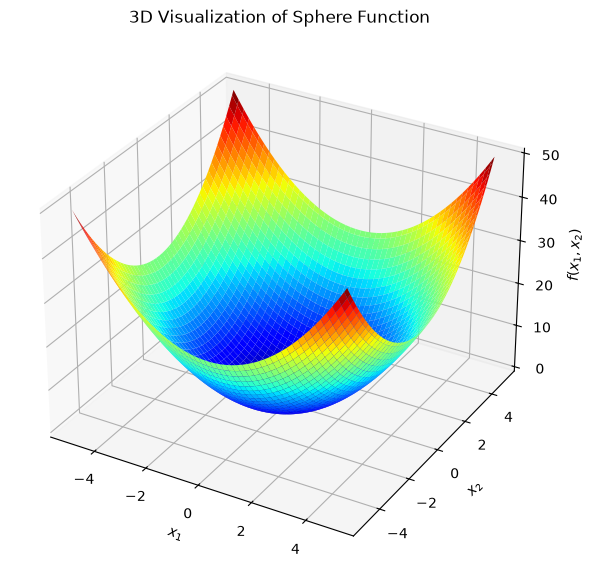

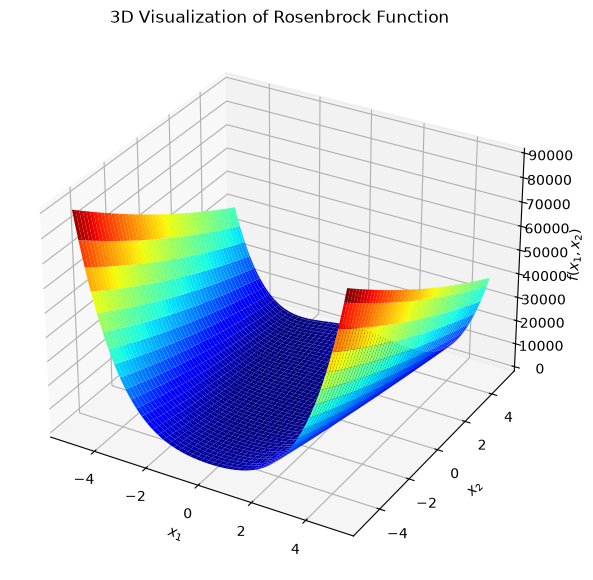

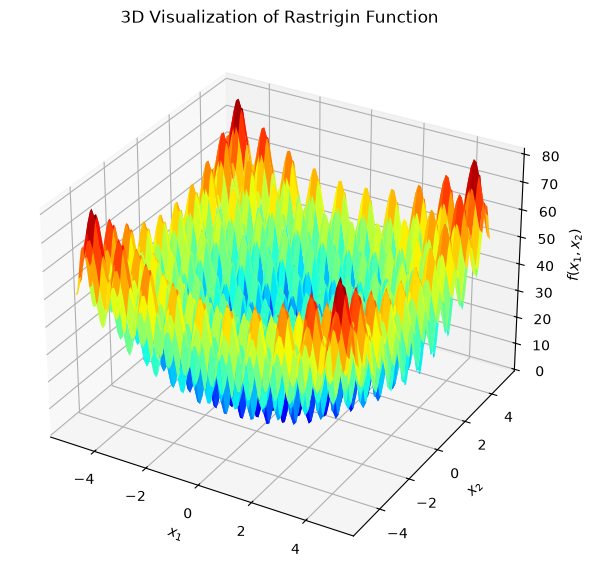

In [4]:
# 3D Visualizations
vis3d(sphere, name='Sphere')
vis3d(rosenbrock, name='Rosenbrock')
vis3d(rastrigin, name='Rastrigin')

### SELF-REFLECT QUESTION
Which function might be the hardest to optimize (for fixed budget)?

#### Template Optimizer
In the context of Black-Box Optimization, we work in the context of Fixed Budget Evaluation as we want to assess the optimizer based on how close the optimizer get to a close to optimum function evaluation with the less number of evaluations possible. 

You may wonder what's required for a single objective optimization process from an implementation level. Namely, the elements are:
- A callable function which computes the objective.
- The **bounds** of each of the design variables involved in the optimization. For most of the benchmarks the bounds are set as default to be $[-5,5]$ for each if the design variables.
- The **dimension** of the problem.

##### Special Requirements
Since we're working with randomized algorithms, we require a **random seed** or a default **Random Number Generator** such that the repeatibility of the optimization process is ensured.

As always, each algorithm comes with its own set of **hyperparameters** which must be handled.

In [5]:
from abc import ABC, abstractmethod
from typing import Callable, Optional, Union

class AbstractOptimizer(ABC):
    """Abstract base class for optimization algorithms."""
    def __init__(self, 
                 dim:int, 
                 lb:Optional[Union[int,float,np.ndarray]]=-5.0, 
                 ub:Optional[Union[int,float,np.ndarray]]=5.0,
                 **kwargs)->None:
        '''
        Parameters
        ----------
        
        dim : int
            The dimensionality of the input space.
        lb : int, float or np.ndarray
            The lower bound(s) for the input space.
        ub : int, float or np.ndarray
            The upper bound(s) for the input space.
        **kwargs : dict
            Additional hyperparameters for the optimizer.

        '''

        self.dim = dim
        self.hyperparameters = kwargs
        self.lb = lb
        self.ub = ub
        ...

    @abstractmethod
    def __call__(self, 
                 func:Callable, 
                 budget:int, 
                 random_seed:int=43, 
                 **kwds)->dict:
        '''
        Parameters
        ----------
        func : callable
            The objective function to be minimized.
        budget : int
            The total number of function evaluations allowed.
        random_seed : int
            Seed for random number generator to ensure reproducibility.
        **kwds : dict
            Additional parameters for the optimizer. Normally assigned to hardware settings.
        Returns
        -------
        dict
            A dictionary containing the optimization results.
        '''

        assert callable(func), "The objective function must be callable."
        assert isinstance(budget, int) and budget > 0, "Budget must be a positive integer."
        assert isinstance(random_seed, int), "Random seed must be an integer."
        

        ...
    
    @abstractmethod
    def run(self, func:Callable, budget:int, random_seed=43, **kwds)->dict:
        '''
        A wrapper method to call the optimizer.
        '''
        self.__call__(func, budget, random_seed, **kwds)
    

    @property
    def dim(self)->int:
        """
        The dimensionality of the input space.
        """
        return self._dim
    
    @dim.setter
    def dim(self, d:int)->None:
        if not isinstance(d, int) or d <= 0:
            raise ValueError("Dimension must be a positive integer.")
        self._dim = d
    
    @property
    def lb(self)->np.ndarray:
        '''
        The lower bound(s) for the input space.
        '''
        return self._lb
    
    @lb.setter
    def lb(self, lb:Union[int,float,np.ndarray])->None:
        if isinstance(lb, (int, float)):
            self._lb = np.full(self.dim, lb)
        elif isinstance(lb, np.ndarray):
            if lb.shape != (self.dim,):
                raise ValueError(f"Lower bounds must be a numpy array of shape ({self.dim},).")
            self._lb = lb
        else:
            raise ValueError("Lower bounds must be a float, int, or numpy array.")
    
    @property
    def ub(self)->np.ndarray:
        return self._ub
    
    @ub.setter
    def ub(self, ub:Union[int,float,np.ndarray])->None:
        if isinstance(ub, (int, float)):
            self._ub = np.full(self.dim, ub)
        elif isinstance(ub, np.ndarray):
            if ub.shape != (self.dim,):
                raise ValueError(f"Upper bounds must be a numpy array of shape ({self.dim},).")
            self._ub = ub
        else:
            raise ValueError("Upper bounds must be a float, int, or numpy array.")
        
        if np.any(self._ub <= self.lb):
            raise ValueError("Each upper bound must be greater than the corresponding lower bound.")
    
    @property
    @abstractmethod
    def name(self)->str:
        '''
        The name of the optimization algorithm.
        '''
        ...
        
    
        

#### Genetic Algorithm

In [6]:
# Application of Genetic Algorithm
# pip install pygad

import pygad
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

class GeneticAlgorithm(AbstractOptimizer):
    """ 
    This class implements a Genetic Algorithm optimizer using the pygad library.
    It inherits from the AbstractOptimizer class and provides a concrete implementation
    of the __call__ and run methods.
    """
    def __call__(self, func:Callable, budget:int, random_seed=43, **kwds)->dict:
        """
        This method runs the Genetic Algorithm optimization process.
        It uses the pygad library to perform the optimization.
        
        Parameters
        ----------
        func : callable
            The objective function to be minimized.
        budget : int
            The total number of function evaluations allowed.
        random_seed : int
            Seed for random number generator to ensure reproducibility.
        **kwds : dict
            Additional parameters for the optimizer. Normally assigned to hardware settings.
        Returns
        -------
        dict
            A dictionary containing the best solution found and its fitness value.
            
        """

        assert callable(func), "The objective function must be callable."
        assert isinstance(budget, int) and budget > 0, "Budget must be a positive integer."
        assert isinstance(random_seed, int), "Random seed must be an integer."
        
        # This is a minimization problem, but pygad does maximization
        def fitness_func(ga_instance, solution, solution_idx):
            return -func(solution)

        # Set up the fitness function
        fitness_function = fitness_func

        # Extract hyperparameters or set defaults
        num_parents_mating = self.hyperparameters.get('num_parents_mating', 4)
        sol_per_pop = self.hyperparameters.get('sol_per_pop', 8)
        num_generations = budget // sol_per_pop
        num_genes = self.dim
        init_range_low = self.hyperparameters.get('init_range_low', -2)
        init_range_high = self.hyperparameters.get('init_range_high', 5)
        parent_selection_type = self.hyperparameters.get('parent_selection_type', "sss")
        keep_parents = self.hyperparameters.get('keep_parents', 1)
        crossover_type = self.hyperparameters.get('crossover_type', "single_point")
        mutation_type = self.hyperparameters.get('mutation_type', "random")
        mutation_percent_genes = self.hyperparameters.get('mutation_percent_genes', 10)


        # Get a GA instance from PyGAD
        ga_instance = pygad.GA(num_generations=num_generations,
                            num_parents_mating=num_parents_mating,
                            fitness_func=fitness_function,
                            sol_per_pop=sol_per_pop,
                            num_genes=num_genes,
                            init_range_low=init_range_low,
                            init_range_high=init_range_high,
                            parent_selection_type=parent_selection_type,
                            keep_parents=keep_parents,
                            crossover_type=crossover_type,
                            mutation_type=mutation_type,
                            mutation_percent_genes=mutation_percent_genes,
                            random_seed=random_seed,
                            save_best_solutions=True
                            )
        

        # Run the GA
        ga_instance.run()
        
        return {
            'best_solution': ga_instance.best_solution()[0].tolist(),
            'best_fitness': -ga_instance.best_solution()[1]
        }

    def run(self, func:Callable, budget:int, **kwds)->dict:
        return self.__call__(func, budget, **kwds)
    
    @property
    def name(self)->str:
        return "Genetic Algorithm"
        
       

# Run the Genetic Algorithm
GeneticAlgorithm(dim=2).run(func=rosenbrock, budget=100, random_seed=58)

{'best_solution': [0.4921206157462572, 0.2538166327611988],
 'best_fitness': np.float64(0.27147630706962483)}

#### Differential Evolution

In [7]:
# Application of Differential Evolution
# pip install scipy

from scipy.optimize import differential_evolution
from math import floor

class DifferentialEvolution(AbstractOptimizer):
    
    def __call__(self, 
                 func:Callable,
                 budget:int,
                 random_seed=43,
                 **kwds)->dict:
        
        """
        This method runs the Differential Evolution optimization process.
        It uses the scipy library to perform the optimization.
        
        Parameters
        ----------
        func : callable
            The objective function to be minimized.
        budget : int
            The total number of function evaluations allowed.
        random_seed : int
            Seed for random number generator to ensure reproducibility.
        **kwds : dict
            Additional parameters for the optimizer. Normally assigned to hardware settings.
        
        Returns
        -------
        dict
            A dictionary containing the best solution found and its fitness value.
        """

        assert callable(func), "The objective function must be callable."
        assert isinstance(budget, int) and budget > 0, "Budget must be a positive integer."
        assert isinstance(random_seed, int), "Random seed must be an integer."
        
        workers = kwds.get('workers', 1)
        tol = kwds.get('tol', 0.01)
        disp = kwds.get('disp', False)

        strategy = self.hyperparameters.get('strategy', 'best1bin')
        mutation = self.hyperparameters.get('mutation', (0.5, 1))
        recombination = self.hyperparameters.get('recombination', 0.7)

        init = self.hyperparameters.get('init', 'latinhypercube')

        # IMPORTANT: In SciPy, popsize is a multiplier. Actual population = popsize * dim
        pop_mult = int(self.hyperparameters.get('popsize', 15))  # default SciPy behavior
        if pop_mult < 1:
            pop_mult = 1

        # Shrink population multiplier if it would already exceed the budget
        # Initial population requires NP evaluations.
        NP = pop_mult * self.dim
        if NP > budget:
            pop_mult = max(1, budget // self.dim)
            NP = pop_mult * self.dim
            if NP == 0:
                raise ValueError(
                    f"Budget {budget} too small for dimension {self.dim}. "
                    "Increase budget or reduce dimension."
                )

        # Now choose maxiter so total evals ≤ budget:
        # nfev ≈ NP (initial) + maxiter * NP  => maxiter ≤ floor((budget - NP)/NP)
        if budget < NP:
            maxiter = 0
        else:
            maxiter = floor((budget - NP) / NP)
        if maxiter < 0:
            maxiter = 0

        
        

        # Define the bounds for each dimension
        bounds = [(self.lb[i], self.ub[i]) for i in range(self.dim)]
        
        # Run the differential evolution algorithm
        result = differential_evolution(func, 
                                        bounds, 
                                        maxiter=maxiter+1, 
                                        popsize=pop_mult,
                                        workers=workers,
                                        tol=tol,
                                        strategy=strategy,
                                        mutation=mutation,
                                        recombination=recombination,
                                        disp=disp,
                                        polish=False,
                                        seed=random_seed,
                                        init=init)
        return {
            'best_solution': result.x.tolist(),
            'best_fitness': result.fun
        }

    def run(self, func:Callable, budget:int, random_seed:int=43, **kwds)->dict:
        return self.__call__(func,
                             budget, 
                             random_seed,
                             **kwds)
    @property
    def name(self)->str:
        return "Differential Evolution"
    

DifferentialEvolution(dim = 2, 
                      recombination=0.7,
                      strategy="best1bin").run(func=rosenbrock,budget=100, random_seed=43, disp=False)

{'best_solution': [-0.24316510308499795, 0.18106750509346847],
 'best_fitness': np.float64(3.032352855723261)}

## Exercise 1
Implement the wrapper class of a Bayesian Optimization loop. For this case, make use of the function `skopt.gp_minimize`. For the implementation you may check the following tutorial: https://scikit-optimize.github.io/0.7/auto_examples/bayesian-optimization.html#sphx-glr-auto-examples-bayesian-optimization-py.

To set up the space, look up to `skopt.space.Real` to set up the bounds (notice that BO pipelines can take also categorical and integer values and are not constrained to Real Spaces). Take a look at the hyperparameters `n_initial_points`, `acq_func`, `acq_optimizer` and `initial_point_generator` from `skopt.gp_minimize`. In your implementation extract the values of this hyperparameters from `self.hyperparameters`.
#### Bayesian Optimization

In [9]:
# Application of Bayesian Optimization
# pip install scikit-optimize

from skopt import gp_minimize
from skopt.space import Real


class BayesianOptimization(AbstractOptimizer):
    def __call__(self, 
                 func:Callable,
                 budget:int,
                 random_seed=43,
                 **kwds)->dict:
        
        """
        This method runs the Bayesian Optimization process.
        It uses the `skopt` package to perform the optimization.
        
        Parameters
        ----------
        func : callable
            The objective function to be minimized.
        budget : int
            The total number of function evaluations allowed.
        random_seed : int
            Seed for random number generator to ensure reproducibility.
        **kwds : dict
            Additional parameters for the optimizer. Normally assigned to hardware settings.
        
        Returns
        -------
        dict
            A dictionary containing the best solution found and its fitness value.
        """
        

        # Define the bounds for each dimension of the search space
        space = [Real(self.lb[ii], self.ub[ii]) for ii in range(self.dim)]

        # TODO: IMPLEMENT THIS METHOD TO RUN BAYESIAN OPTIMIZATION
        
        acq_func = self.hyperparameters.get("acq_func", "gp_hedge")

        acq_optimizer = self.hyperparameters.get("acq_optimizer", "lbfgs")

        n_initial_doe = self.hyperparameters.get("n_initial_points", 2)

        initial_point_generator = self.hyperparameters.get("initial_point_generator", "random")

        
        
        result = gp_minimize(func,                  # the function to minimize
                  space,      # the bounds on each dimension of x
                  acq_func=acq_func,      # the acquisition function
                  n_calls=budget,         # the number of evaluations of f
                  n_random_starts=n_initial_doe,  # the number of random initialization points
                  noise=0.1**2,       # the noise level (optional)
                  random_state=random_seed, # the random seed
                  initial_point_generator=initial_point_generator,

                  )   


        # END TODO

    
        return {
            'best_solution': result.x,
            'best_fitness': result.fun
        }

    def run(self, func:Callable, budget:int, random_seed:int=43, **kwds)->dict:
        return self.__call__(func, 
                             budget, 
                             random_seed,
                             **kwds)

    @property
    def name(self)->str:
        return "Bayesian Optimization"
    
    

BayesianOptimization(dim=2, n_initial_points=2).run(rosenbrock,budget=100, random_seed=63)

{'best_solution': [-0.17550731960464816, -0.04278521937447799],
 'best_fitness': np.float64(1.9233374010802828)}

## Exercise 2: Application of optimization algorithms
So far we minimized the `rosenbrock` function. Apply `GA`, `DE` and `BO` to minimize the `rastrigin` and `sphere` functions. Change the random seed and see how the algorithms rank and how close they got to the optimum in each of the two problems.

In [11]:
def run_pipeline(random_seed, budget):
    res_bo = BayesianOptimization(dim=2, n_initial_points=2).run(rosenbrock,budget=budget, random_seed=random_seed)
    res_ga = GeneticAlgorithm(dim=2).run(func=rosenbrock, budget=budget, random_seed=random_seed)
    res_de = DifferentialEvolution(dim = 2, 
                        recombination=0.7,
                        strategy="best1bin").run(func=rosenbrock,budget=budget, random_seed=random_seed, disp=False)
    return res_bo, res_ga, res_de

In [12]:
random_seed = 102
budget = 100

# TODO: Your code goes here for Sphere function

res_bo, res_ga, res_de = run_pipeline(random_seed, budget)
print("Bayesion Optimization\n----------------\n", res_bo, "\n")
print("Genetic Algorithm\n----------------\n", res_ga, "\n")
print("Differential Evolution\n----------------\n", res_de, "\n")

# END TODO


Bayesion Optimization
----------------
 {'best_solution': [-1.4353354680711972, 2.061221569595709], 'best_fitness': np.float64(5.930965688108485)} 

Genetic Algorithm
----------------
 {'best_solution': [0.4374743900521081, 0.2541537405312062], 'best_fitness': np.float64(0.7104410786183599)} 

Differential Evolution
----------------
 {'best_solution': [0.7124400435258849, 0.36325830455459673], 'best_fitness': np.float64(2.165300813543501)} 



In [13]:
random_seed=48
budget = 100

# TODO: Your code goes here for Rastrigin function


res_bo, res_ga, res_de = run_pipeline(random_seed, budget)
print("Bayesion Optimization\n----------------\n", res_bo, "\n")
print("Genetic Algorithm\n----------------\n", res_ga, "\n")
print("Differential Evolution\n----------------\n", res_de, "\n")


# END TODO

Bayesion Optimization
----------------
 {'best_solution': [-0.6430821358456988, 0.4084318987878337], 'best_fitness': np.float64(2.702343146170875)} 

Genetic Algorithm
----------------
 {'best_solution': [0.3168148021088042, 0.0928346422127051], 'best_fitness': np.float64(0.4724226162784973)} 

Differential Evolution
----------------
 {'best_solution': [0.7548881022906639, 0.579426581857595], 'best_fitness': np.float64(0.0692393561829984)} 



## Part 2: IOH & BBOB

```mermaid
flowchart TD
    A["Working with Metaheuristics"]
    B["Runs"]
    C["Algorithm"]
    D["Logging"]
    E["Post-processing"]

    A -->|"Set a number of runs"| B
    B -->|"Repeat until the specified<br/>number of operations"| C
    C --> D
    D -.-> E

    classDef title font-size:17px,font-weight:bold
    classDef process fill:#ffffff,stroke:#000000,stroke-width:1px

    class A title
    class A,B,C,D,E process
```

### Explanation
- "Randomized Optimization Algorithms" do not have a guaranteed convergence to optima (++ After a finite number of steps the meta-heuristics might not get to the optima of a function). Therefore, to assess the performance of a meta-heuristic, several runs shall be made, wherein it's expected the algorithm to yield values close to the optima in a consistent manner. 
- Different initial conditions "might" yield difference results.
- The "No free lunch theorem":
    + Some algorithms might perform well for certain landscapes (optimization problems) at the expense of not performing well in others. 
    + To assess a overall performance of a meta-heuristic, it should be tested for different problems (functions).


### Continuous Black-box Optimization Benchmarks (CoCo - BBOB)
- Set of 24 Benchmark problems to assess performance of black-box optimizers.
- Key Concepts:
    + Taxonomy: Problems of the Benchmarks are classified into 5 subgroups: 1) Separable; 2) Unimodal with low/moderate conditioning; 3) Unimodal with high conditioning; 4) Multi-modal with (moderate) global structure and 5) Multi-modal with weak global structure. 
    + Instances: To avoid repeating the same problems (as before), the landscapes of a base problem are transformed (through rotation, reflection and translation).

For more information on BBOB, please check: https://coco-platform.org/testsuites/bbob/overview.html

### Framework
In this section, we will work with the IOH Framework (Jacob de Nobel, Furong Ye, Diederick Vermetten, Hao Wang, Carola Doerr and Thomas Bäck, IOHexperimenter: Benchmarking Platform for Iterative Optimization Heuristics, arXiv e-prints:2111.04077, 2021.)

This framework facilitates the logging process and enables to follow-up the workflow shown before. For more details, check: https://github.com/IOHprofiler/IOHexperimenter.

If you would like more insight on how to use the toolbox, go to:
- Jupyter Notebook example: https://github.com/IOHprofiler/IOHexperimenter/blob/master/example/tutorial.ipynb
- Plain code example: https://iohprofiler.github.io/IOHexperimenter/python

In [ ]:
# This is a prelude to manage the files that will be generated during this exercise
import os
import glob

from shutil import rmtree

def clean():
    for name in ("my-experiment", "ioh_data"):
        for path in glob.glob(f"{name}*"):
            if os.path.isfile(path):
                os.remove(path)
            if os.path.isdir(path):
                rmtree(path, ignore_errors=True)

def ls(p="./"):
    for obj in os.listdir(os.path.normpath(p)):
        print(obj)

def cat(f):
    with open(os.path.normpath(f)) as h:
        print(h.read())

clean()

In [ ]:
# Import the IOH library
# pip install ioh
import ioh

# Import numpy ## For Numerical Processing
import numpy as np

# Import pyplot ## For plotting purposes
import matplotlib.pyplot as plt

# Import the iohinspector Data Manage, the function `turbo_align` and polars
from iohinspector import DataManager
from iohinspector import turbo_align

import polars as pl

IOH enables to call functional evaluations in a modular manner. For this example on usage IOH has incorporated sample functions from both COCO/BBOB benchmarks. The signature uses the Problem class within IOH.

For example, with IOH the Rosenbrock function can be called as follows:

In [ ]:
rosenbrock_2d_problem = ioh.get_problem(
    "Rosenbrock", 
    instance=1,
    dimension=2,
    problem_class=ioh.ProblemClass.REAL
)

Other functions, such as the Sphere Function, could be called too. The numbering is performed according to the order in the BBOB (the Sphere function is ordered as the first one):

In [ ]:
sphere_2D_problem = ioh.get_problem(
    1, 
    instance=1,
    dimension=2,
    problem_class=ioh.ProblemClass.REAL
)

**Important**

Whenever a `Problem` is called from IOH, the defined optimum ${\mathbf{x}_{\text{opt}},f_{\text{opt}}}$ changes. This condition could be accessed by using the property `*.optimum`.

In [ ]:
rosenbrock_2d_problem.optimum

## Exercise 3
Generate a loop to plot the contours of the first three instances of the Sphere Function and the optimum of it. In order to have access to the optimal point, you might call `sphere_2D_problem.optimum.x`. For plotting, you may use the `contour()` function defined above. Additionally, you may retrieve the name by calling the method `sphere_2D_problem.meta_data.name`.

In [ ]:
for inst in [1,2,3]:

    #TODO: Your code goes here for the Sphere function

    
    # END TODO

Repeat this with Function #12 or **Bent-Cigar** function. Are there rotations?

In [ ]:
#TODO: Your code goes here for the Sphere function
for inst in [1,2,3]:

    
# END TODO

## Part 3: Performing experiments with IOH and Logging
An experiment with arbitrary number of runs would look like this. Notice the usage of the attributes of a `IOH-Experimenter Problem` instance to access the metadata and current state of an optimization run.

In [ ]:

n_runs = 3
budget = 100

for algorithm_class, problem in zip([GeneticAlgorithm, DifferentialEvolution, BayesianOptimization],[rosenbrock_2d_problem]*3):

    # Initialize the algorithm with the problem dimension and bounds
    algorithm = algorithm_class(dim=problem.meta_data.n_variables,
                                lb = problem.bounds.lb,
                                ub = problem.bounds.ub
                                )
    # IOH implements a reset method to restart the problem state
    problem.reset()
    
    print(f"\nAlgorithm: {algorithm.name} - Function: {problem.meta_data.name}  - Instance: {problem.meta_data.instance} - Dimension: {problem.meta_data.n_variables}")
    for run in range(n_runs):

        # Run the algorithm
        algorithm.run(problem,budget=budget, random_seed=run+45)

        # print the best found for this run
        print(f"run: {run+1} - best found:{problem.state.current_best.y: .3f}"\
              f" - regret:{abs(problem.state.current_best.y-problem.optimum.y): .3f}"\
              f" - num evals: {problem.state.evaluations}")
        problem.reset()
    

For logging, a small modification from previous block is applied by setting up a logger object compatible with IOH.

In [ ]:
n_runs = 5
budget = 100

# Presets for logging

# Set the trigger characteristics (when to save evaluations done by the algorithm)
triggers = [
    ioh.logger.trigger.Each(5), # Log every (n) evaluations
    ioh.logger.trigger.OnImprovement() # On every improvement
]

# Set the properties to be logged (what to save)
additional_properties = [ioh.logger.property.CURRENTY,  # This is to log the current function value
                         ioh.logger.property.RAWYBEST, # This is to log the best-so-far regret
                         ioh.logger.property.CURRENTBESTY] # This is to log the best-so-far function value

# Root directory to store the data
root_directory = os.getcwd()

# Base Folder name to store the data
base_folder_name = "my-experiment"

# This is to store the (design) points evaluated during the optimization
store_positions = True 


for algorithm_class, problem in zip([GeneticAlgorithm, DifferentialEvolution, BayesianOptimization],[rosenbrock_2d_problem]*3):

    # Initialize the algorithm with the problem dimension and bounds
    algorithm = algorithm_class(dim=problem.meta_data.n_variables,
                                lb = problem.bounds.lb,
                                ub = problem.bounds.ub
                                )
    
    # Restart the problem state
    problem.reset()

    # Initialize the logger
    logger = ioh.logger.Analyzer(
        root=root_directory,
        folder_name=base_folder_name+f"_{algorithm.name}",
        algorithm_name=algorithm.name,
        additional_properties=additional_properties,
        triggers=triggers,
        store_positions=store_positions
    )

    # Attach the logger to the problem
    problem.attach_logger(logger)
    
    
    print(f"\nAlgorithm: {algorithm.name} - Function: {problem.meta_data.name}  - Instance: {problem.meta_data.instance} - Dimension: {problem.meta_data.n_variables}")
    for run in range(n_runs):

        # Run the algorithm
        algorithm.run(problem,budget=budget, random_seed=run+145)

        # print Evaluation Finished
        print(f"run: {run+1} Finished")
        problem.reset()
    
    # Detach the logger from the problem
    problem.detach_logger()

    # Close the logger
    logger.close()



After running the experiment, a folder will appear in your working directory with a JSON file and a folder pointed by the JSON file with the saved results of the experiment by the logger.

## Part 4: Plotting Reference (using `IOH-Inspector` and `IOH-Analyzer`)
This section is for you to use a parser (IOH Inspector) to process the files. The `manager` keeps track of every possible run by linking a folder to it.

For more information on `IOH-Inspector`, check https://github.com/IOHprofiler/IOHinspector/tree/main.

In [ ]:
manager = DataManager()
manager.add_folder("my-experiment_Genetic Algorithm")
manager.add_folder("my-experiment_Differential Evolution")
manager.add_folder("my-experiment_Bayesian Optimization")

What the `manager` loads first are the `JSON` files with the metadata of each of the runs.

In [ ]:
# Prints the experiments
manager.overview

In [ ]:
# Load the performance data
df = manager.load(monotonic=True,
                  include_meta_data=True)

# Align the data (you can also use the function `align_data` from iohinspector)
df = turbo_align(df,x_values=[*range(1,103,5)],x_col="evaluations",y_col="raw_y", maximization=False)

In [ ]:
# TODO: Run this block to see the dataframe with all the retrieved data
df

`IOH-Inspector` extends the library `polars` in order to retrieve all the data. You can manipulate the databases for plotting and statistical purposes by following `polars` framework.

In [ ]:
# This block is to make a plot of each run of the experiment
fig, ax = plt.subplots(figsize=(10, 7))
linestyles = ['-', '-.', ':']
colors = ['blue', 'red', 'green', 'magenta', 'cyan']

for idx_alg, algorithm in enumerate(df['algorithm_name'].unique()):
    # Filter the dataframe for the current algorithm
    df_algo = df.filter(pl.col('algorithm_name') == algorithm)
    
    for idx_run, run in enumerate(df_algo['run_id'].unique()):

        # Filter the dataframe for the current run
        df_run = df_algo.filter(pl.col('run_id') == run)
        ax.plot(df_run['evaluations'], df_run['raw_y_best'], 
                label=f'Run {run}_{algorithm}',
                linestyle=linestyles[idx_alg],
                color = colors[idx_run])

ax.grid(True)
ax.set_xlabel('Function Evaluations')
ax.set_ylabel('Regret')
ax.set_yscale('log')
ax.set_title('Convergence Plot per Run')
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='xx-small')
plt.tight_layout()  # Adjust layout to prevent clipping)
        


You may also have a compact version of the visuals above by computing the mean and standard error of the experiments done before by aggregating by each algorithm.

In [ ]:
# Convergence plot: mean ± SE across runs for each algorithm
fig, ax = plt.subplots(figsize=(10, 7))

for algorithm in df.get_column('algorithm_name').unique().to_list():
    # Filter this algorithm
    df_algo = df.filter(pl.col('algorithm_name') == algorithm)

    # Aggregate stats per evaluation count
    df_stats = (
        df_algo
        .group_by('evaluations')
        .agg(
            mean_regret = pl.col('raw_y_best').mean(),
            std_regret  = pl.col('raw_y_best').std(),     # sample std (ddof=1)
            n           = pl.len()
        )
        .with_columns(
            se_regret = pl.col('std_regret') / pl.col('n').sqrt()
        )
        .select(['evaluations', 'mean_regret', 'se_regret'])
        .sort('evaluations')
    )

    x = df_stats['evaluations'].to_numpy()
    m = df_stats['mean_regret'].to_numpy()
    se = df_stats['se_regret'].to_numpy()*1.2 # 95% Confidence Interval

    ax.plot(x, m, label=str(algorithm), linestyle='--', linewidth=2)
    ax.fill_between(x, m - se, m + se, alpha=0.2, linewidth=0)

ax.grid(True, which='both', alpha=0.3)
ax.set_xlabel('Function Evaluations')
ax.set_ylabel('Mean Regret')
ax.set_yscale('log')  # ensure regrets are strictly > 0
ax.set_title('Convergence (mean ± SE)')

# Place legend outside the plot
leg = ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='xx-small', frameon=False)
plt.tight_layout()


`IOH-Inspector` has some plotting functions to visualize aggregated measures (such as mean) of each of the methods.

In [ ]:
# Modify the plot to have the Standard error

from iohinspector.plot import single_function_fixedbudget
fig, ax = plt.subplots(figsize=(10, 7))
data_singlefb = single_function_fixedbudget(df, maximization=False, measures=["mean"], ax=ax, scale_xlog=False)

# Modification of the legend
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
ax.invert_xaxis() # This is used since the default behavior is to have the x-axis in decreasing order
ax.set_title('Fixed-Budget Plot - Mean Regret')

A tool called `IOH Analyzer` is available from https://iohanalyzer.liacs.nl/. To use the tool, the results should be zipped and uploaded to the platform.

### Extra Exercise: Understading classical functions
 - Prove that $x^* = (1, 1)^\top$ is the unique local minimum of the Rosenbrock function (with $a=1$ and $b=100$).
